# Phishing Incident Report Analysis

**Name:** Prayas Palit  
**Roll No:** B230058EC  
**Domain:** Cybersecurity  
**Dataset Source:** PhishTank

This notebook checks null values, duplicate values, removes them, and shows a simple analysis of phishing targets.

## Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


## Load Dataset

In [2]:
file_path = r"E:\GNCIPIL\WEEK 1\phishtank_online_valid.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


## Show First Rows

In [3]:
print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
   phish_id                                                url  \
0   9445359  https://allegrolokalnie.689575gg.top/oferta/id...   
1   9445345  https://allegrolokalnie.70192.top/oferta/id-x4...   
2   9445332                               https://kkugames.com   
3   9445331                             https://songbaiyao.com   
4   9445330                             https://orange-tzh.com   

                                    phish_detail_url  \
0  http://www.phishtank.com/phish_detail.php?phis...   
1  http://www.phishtank.com/phish_detail.php?phis...   
2  http://www.phishtank.com/phish_detail.php?phis...   
3  http://www.phishtank.com/phish_detail.php?phis...   
4  http://www.phishtank.com/phish_detail.php?phis...   

             submission_time verified          verification_time online  \
0  2026-06-06T08:20:43+00:00      yes  2026-06-06T08:52:23+00:00    yes   
1  2026-06-06T06:35:53+00:00      yes  2026-06-06T06:52:17+00:00    yes   
2  2026-06-0

## Check Dataset Size

In [4]:
print("Number of rows and columns:")
print(df.shape)

print("Column names:")
print(df.columns)

Number of rows and columns:
(63956, 8)
Column names:
Index(['phish_id', 'url', 'phish_detail_url', 'submission_time', 'verified',
       'verification_time', 'online', 'target'],
      dtype='object')


## Statistical Summary

In [5]:
df["url_length"] = df["url"].str.len()

print("Statistical summary of numerical columns:")
print(df[["phish_id", "url_length"]].describe())

Statistical summary of numerical columns:
           phish_id    url_length
count  6.395600e+04  63956.000000
mean   8.975182e+06     57.995075
std    4.687638e+05    158.405524
min    1.123978e+06     12.000000
25%    8.673221e+06     25.000000
50%    9.154154e+06     38.000000
75%    9.386731e+06     57.000000
max    9.445359e+06  25523.000000


## Check Null Values

In [6]:
print("Null values in each column:")
print(df.isnull().sum())

print("Total null values:")
print(df.isnull().sum().sum())

Null values in each column:
phish_id             0
url                  0
phish_detail_url     0
submission_time      0
verified             0
verification_time    0
online               0
target               0
url_length           0
dtype: int64
Total null values:


0


## Show Rows With Null Values

In [7]:
rows_with_null = df[df.isnull().any(axis=1)]

print("Number of rows with null values:")
print(len(rows_with_null))

if len(rows_with_null) == 0:
    print("No rows with null values found.")
else:
    print(rows_with_null)

Number of rows with null values:
0
No rows with null values found.


## Check Duplicate Rows

In [8]:
duplicate_rows = df[df.duplicated()]

print("Number of complete duplicate rows:")
print(len(duplicate_rows))

if len(duplicate_rows) == 0:
    print("No complete duplicate rows found.")
else:
    print(duplicate_rows)

Number of complete duplicate rows:


0
No complete duplicate rows found.


## Check Duplicate URLs

In [9]:
duplicate_urls = df["url"].duplicated().sum()

print("Number of duplicate URLs:")
print(duplicate_urls)

duplicate_url_rows = df[df["url"].duplicated(keep=False)]

print("Rows having duplicate URLs:")
if len(duplicate_url_rows) == 0:
    print("No duplicate URL rows found.")
else:
    print(duplicate_url_rows[["phish_id", "url", "target"]].sort_values("url"))

Number of duplicate URLs:
7
Rows having duplicate URLs:
       phish_id                                                url target
34101   9072286                    https://bellsrdyfuv.weebly.com/  Other
34148   9069032                    https://bellsrdyfuv.weebly.com/  Other
34108   9072236                   https://secureptddff.weebly.com/  Other
34155   9068962                   https://secureptddff.weebly.com/  Other
63755   7301069  https://storage.cloud.google.com/1lordman1man3...  Other
63756   7300388  https://storage.cloud.google.com/1lordman1man3...  Other
63757   7299325  https://storage.cloud.google.com/1lordman1man3...  Other
34325   9063559  https://xn--atencialclientgeneralitatdecatalun...  Other
34406   9059843  https://xn--atencialclientgeneralitatdecatalun...  Other
34407   9059842  https://xn--atencialclientgeneralitatdecatalun...  Other
34856   9045993  https://xn--zxxserveidassistnciapercorreuxx021...  Other
34947   9039349  https://xn--zxxserveidassistnciapercorr

## Remove Duplicate URLs And Null Values

In [10]:
df_no_duplicates = df.drop_duplicates(subset=["url"], keep="first")

clean_df = df_no_duplicates.dropna()
clean_df = clean_df.copy()

print("Rows before cleaning:")
print(len(df))

print("Rows after removing duplicate URLs:")
print(len(df_no_duplicates))

print("Rows after removing null values:")
print(len(clean_df))

print("Total rows removed:")
print(len(df) - len(clean_df))

Rows before cleaning:
63956
Rows after removing duplicate URLs:
63949
Rows after removing null values:
63949
Total rows removed:
7


## Final Check

In [11]:
print("Null values after cleaning:")
print(clean_df.isnull().sum().sum())

print("Duplicate URLs after cleaning:")
print(clean_df["url"].duplicated().sum())

print("Complete duplicate rows after cleaning:")
print(clean_df.duplicated().sum())

Null values after cleaning:
0
Duplicate URLs after cleaning:
0
Complete duplicate rows after cleaning:


0


## Simple Analysis: Top Phishing Targets

In [12]:
target_data = clean_df[clean_df["target"] != "Other"]

target_reports = target_data.groupby("target")["url"].count()
target_reports = target_reports.sort_values(ascending=False).head(5)

print("Top 5 phishing targets excluding Other:")
print(target_reports)

Top 5 phishing targets excluding Other:
target
Allegro                     1736
Internal Revenue Service     832
Facebook                     347
Microsoft                    273
Bradesco                     243
Name: url, dtype: int64


## Bar Chart: Top Phishing Targets

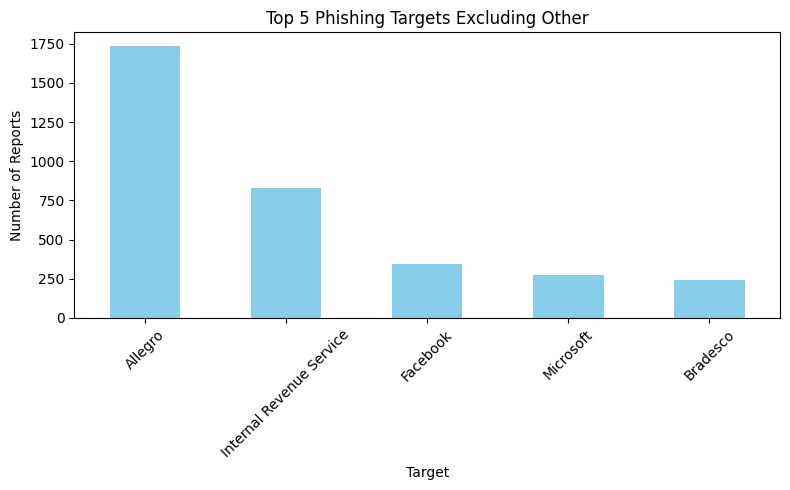

In [13]:
target_reports.plot(kind="bar", color="skyblue", figsize=(8, 5))

plt.title("Top 5 Phishing Targets Excluding Other")
plt.xlabel("Target")
plt.ylabel("Number of Reports")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Simple Analysis: URL Length

In [14]:
print("URL length summary:")
print(clean_df["url_length"].describe())

URL length summary:
count    63949.000000
mean        57.994887
std        158.414063
min         12.000000
25%         25.000000
50%         38.000000
75%         57.000000
max      25523.000000
Name: url_length, dtype: float64


## Histogram: URL Length

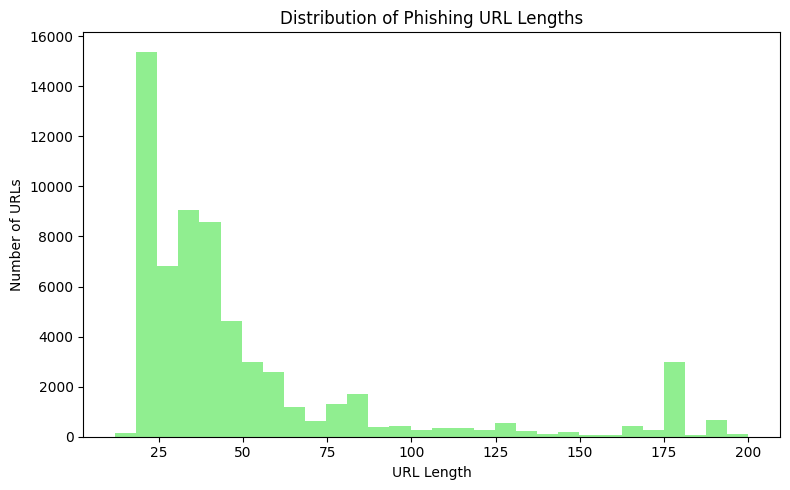

In [15]:
url_length_chart_data = clean_df[clean_df["url_length"] <= 200]

url_length_chart_data["url_length"].plot(kind="hist", bins=30, color="lightgreen", figsize=(8, 5))

plt.title("Distribution of Phishing URL Lengths")
plt.xlabel("URL Length")
plt.ylabel("Number of URLs")
plt.tight_layout()
plt.show()

## Save Cleaned Dataset

In [16]:
cleaned_file_path = r"E:\GNCIPIL\WEEK 1\cleaned_phishtank_dataset.csv"

clean_df.to_csv(cleaned_file_path, index=False)

print("Cleaned dataset saved successfully.")
print(cleaned_file_path)

Cleaned dataset saved successfully.
E:\GNCIPIL\WEEK 1\cleaned_phishtank_dataset.csv


## Conclusion

In [17]:
print("Conclusion:")
print("Null values were checked.")
print("Duplicate rows were checked.")
print("Duplicate URLs were removed.")
print("The cleaned dataset was saved.")

Conclusion:
Null values were checked.
Duplicate rows were checked.
Duplicate URLs were removed.
The cleaned dataset was saved.
